In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan # For Homoscedasticity
from statsmodels.stats.diagnostic import het_white # For Homoscedasticity
from statsmodels.formula.api import ols
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
table1 = {"Label data type": ["numeric", "numeric", "categorical"],
         "Feature data type": ["numeric", "categorical", "categorical"],
         "Effect size stat": ["Pearson correlation (r)", "one-way ANOVA (F)", "Pearson chi-square (X^2)"],
         "Visualization": ["Scatterplot", "Bar chart", "Crosstab"]}

table1 = pd.DataFrame(table1)
table1

,Label data type,Feature data type,Effect size stat,Visualization
0,numeric,numeric,Pearson correlation (r),Scatterplot
1,numeric,categorical,one-way ANOVA (F),Bar chart
2,categorical,categorical,Pearson chi-square (X^2),Crosstab


### Assumptions

In order for a Pearson correlation coefficient (r) to be validly interpreted, there are three assumptions that must be met. And the degree to which these assumptions hold true determines the degree to which we can "trust" the r we calculate.

1. Continuous data (is data that is interval or ratio level--meaning that the intervals between adjacent units are equal)
2. Linear relationship (means that the relationship between two variables can be represented by a straight line regardless of the slope or strength of the correlation)
3. Homoskedastic relationship (refers to the consistency or spread of the relationship across all values of x and y)

The family of **non-parametric (a.k.a. distribution-free)** statistics does not depend on normal distribution methods of calculating a correlation coefficient (r). For example, **Kendall's (tau)** or **Spearman's (rho)** correlation coefficient.

### Probability: P-value

In addition to effect size, another statistic that is commonly calculated is the probability that the estimated effect size is due to random *chance*.

The general purpose of statistical analyses is to test **hypotheses**, or at least explore relationships, among variables/features. For example, *do older people cost more money to health insurance providers?* By default, we assume that there is no relationship between age and insurance charges (termed the **null hypothesis**). But if we start to see persistent trends or older people occurring more healthcare charges than younger people in every new data collection, then we reject that null hypothesis and conclude there truly is a relationship between age and insurance cost. But how strong or significant do those trends have to be to reject the null hypothesis? That is the role of the p-value statistic.

P-value is the probability that future data collections will have results at least as extreme as those observed in the test data--assuming that there is actually no relationship. Stated differently, the lower the p-value, the higher the **likelihood** that older people truly do cost more money and our correlation (r) was not due to chance. The generally accepted threshold for p-value is 0.05.

In [15]:
height = [60, 62, 65, 68, 70, 74]
weight = [140, 138, 150, 166, 190, 250]

np.corrcoef(height, weight)

array([[1.        , 0.92989745],
       [0.92989745, 1.        ]])

In [17]:
np.corrcoef(height, weight)[0][1]

0.9298974521408027

In [25]:
df_hw = pd.read_csv("insurance.csv")
df_hw = df_hw.iloc[:,[0,2,3,6]]
df_hw.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [27]:
df.charges.corr(df.bmi)

0.19834096883362892

In [51]:
r, p = stats.pearsonr(df.charges, df.age)
print(f"Correlation: {r:.3}\nP-value: {p:.3}")

Correlation: 0.299
P-value: 4.89e-29


In [61]:
corr_df = pd.DataFrame(columns=["r", "p"])

for col in df:
    if pd.api.types.is_numeric_dtype(df[col]) and col != "charges":
        r, p = stats.pearsonr(df.charges, df[col])
        corr_df.loc[col] = [round(r, 3), round(p,3)]

corr_df

,r,p
age,0.299,0.000
bmi,0.198,0.000
children,0.068,0.013


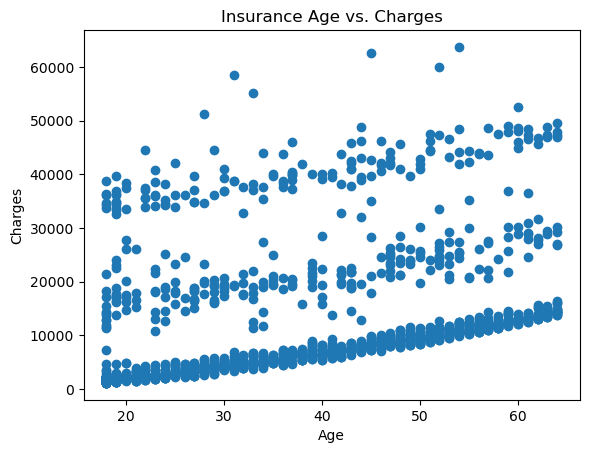

In [121]:
plt.scatter(df.age, df.charges)
plt.title("Insurance Age vs. Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

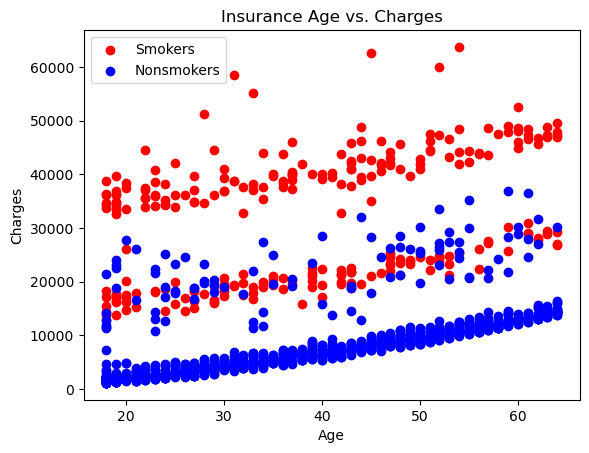

In [125]:
df_smoker = df[df["smoker"] == "yes"]
df_nonsmoker = df[df["smoker"] == "no"]

plt.scatter(df_smoker.age, df_smoker.charges, color="r", label="Smokers")
plt.scatter(df_nonsmoker.age, df_nonsmoker.charges, color="b", label="Nonsmokers")
plt.title("Insurance Age vs. Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend()
plt.show()

In [107]:
temp1 = [1 if i=="yes" else 0 for i in df.smoker]

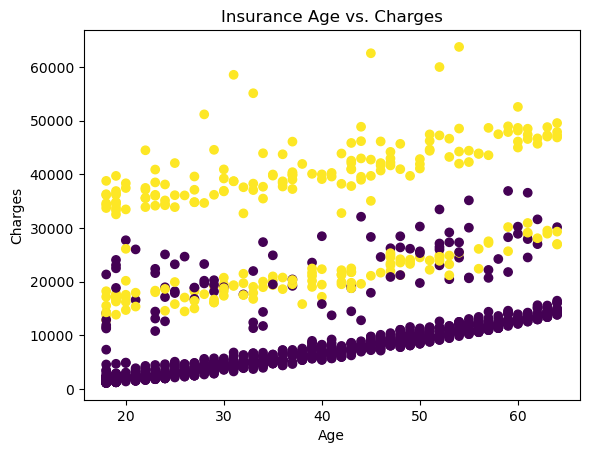

In [109]:
plt.scatter(df.age, df.charges, c=temp1, cmap="viridis")
plt.title("Insurance Age vs. Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

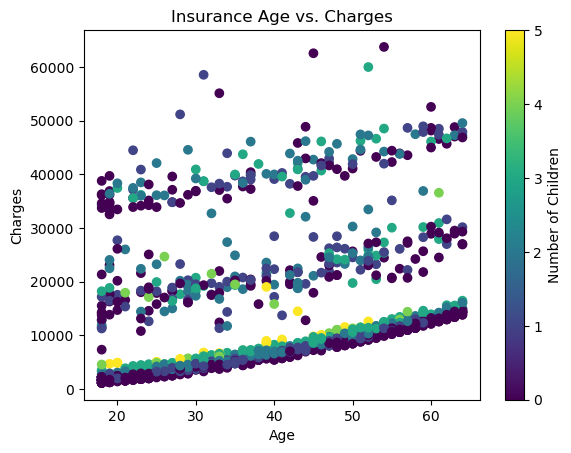

In [117]:
ax = plt.scatter(df.age, df.charges, c=df.children, cmap="viridis")
plt.colorbar(ax, label="Number of Children")
plt.title("Insurance Age vs. Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

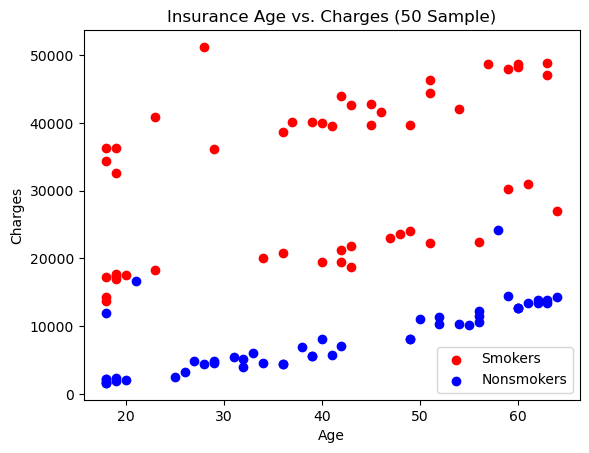

In [127]:
df_smoker_reduced = df_smoker.sample(50)
df_nonsmoker_reduced = df_nonsmoker.sample(50)

plt.scatter(df_smoker_reduced.age, df_smoker_reduced.charges, color="r", label="Smokers")
plt.scatter(df_nonsmoker_reduced.age, df_nonsmoker_reduced.charges, color="b", label="Nonsmokers")
plt.title("Insurance Age vs. Charges (50 Sample)")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend()
plt.show()

In [131]:
print(stats.linregress(df.age, df.charges))
# y = mx + b
# y = slope(x) + intercept

LinregressResult(slope=257.7226186668955, intercept=3165.885006063025, rvalue=0.2990081933306477, pvalue=4.8866933317184915e-29, stderr=22.5023892867703, intercept_stderr=937.1494650703767)


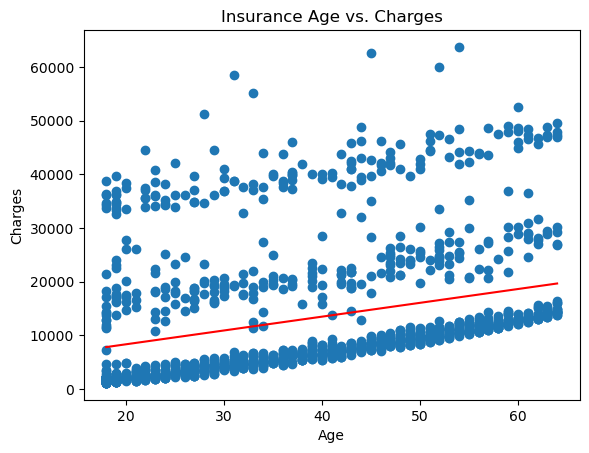

In [135]:
m, b, r, p, err = stats.linregress(df.age, df.charges)
x = range(18, 65)
y = m*x + b

plt.plot(x, y, "r")
plt.scatter(df.age, df.charges)
plt.title("Insurance Age vs. Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

In [159]:
model = ols(formula="charges~age", data=df).fit()

white_test = het_white(model.resid, model.model.exog)
breushp_test = het_breuschpagan(model.resid, model.model.exog)

output_df = pd.DataFrame(columns=["LM stat", "LM p", "F stat", "F stat p"])
output_df.loc["White"] = white_test
output_df.loc["BreushP"] = breushp_test

output_df

,LM stat,LM p,F stat,F stat p
White,0.002713,0.998645,0.001353,0.998648
BreushP,0.000413,0.983776,0.000413,0.983792


In [161]:
model = ols(formula="age~charges", data=df).fit() #order is important

white_test = het_white(model.resid, model.model.exog)
breushp_test = het_breuschpagan(model.resid, model.model.exog)

output_df = pd.DataFrame(columns=["LM stat", "LM p", "F stat", "F stat p"])
output_df.loc["White"] = white_test
output_df.loc["BreushP"] = breushp_test

output_df

,LM stat,LM p,F stat,F stat p
White,113.205738,2.616293e-25,61.695937,2.358806e-26
BreushP,48.227283,3.795702e-12,49.955817,2.525670e-12


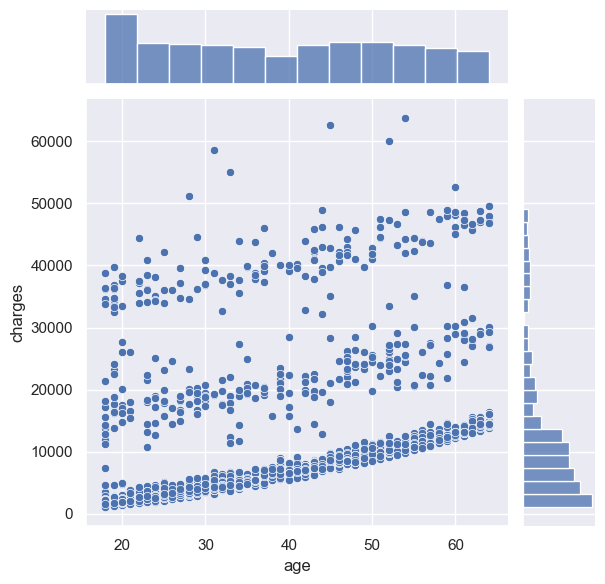

In [169]:
sns.set(color_codes=True)
sns.jointplot(x="age", y="charges", data=df); # ; = plt.show()
#plt.show()

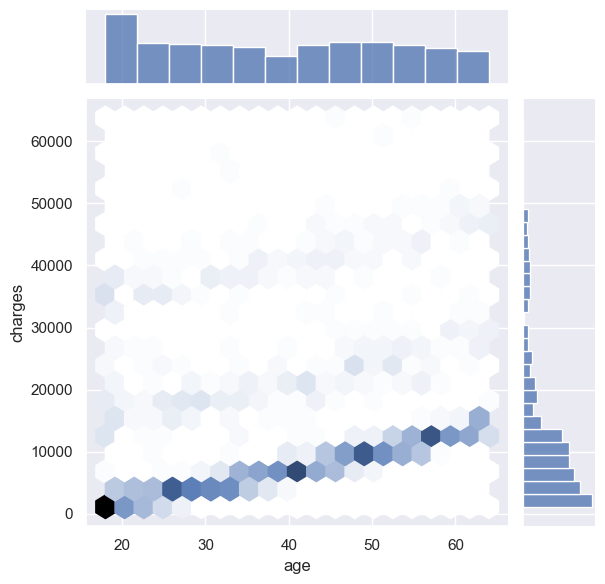

In [171]:
sns.jointplot(x="age", y="charges", data=df, kind="hex"); # hexagonal density

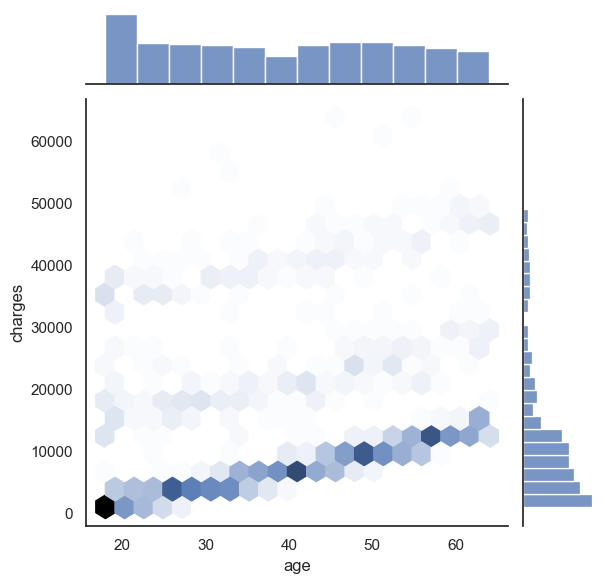

In [173]:
sns.set_style("white")
sns.jointplot(x="age", y="charges", data=df, kind="hex");

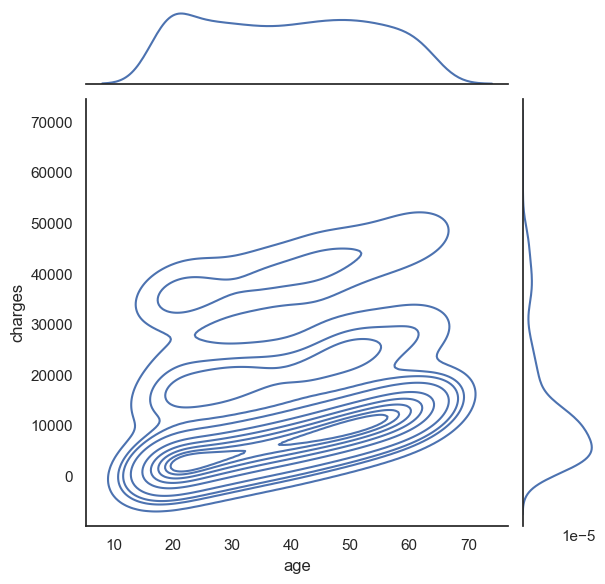

In [175]:
sns.jointplot(x="age", y="charges", data=df, kind="kde"); # kernel density estimation

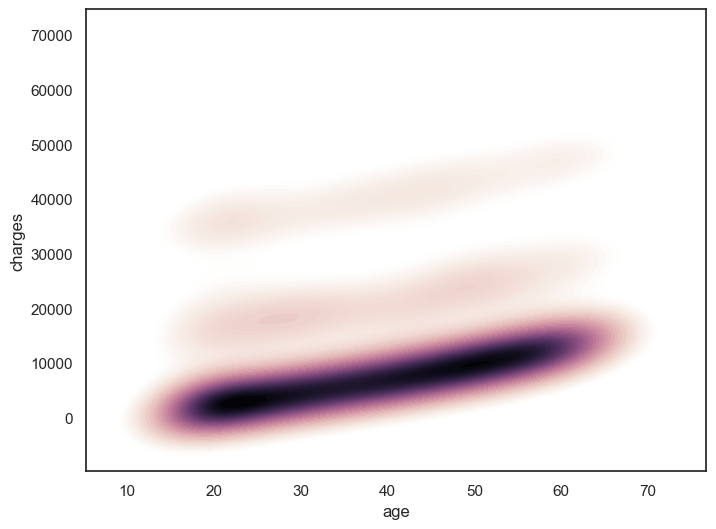

In [187]:
f, ax = plt.subplots(figsize=(8, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=False)
sns.kdeplot(x=df.age, y=df.charges, cmap=cmap, n_levels=60, fill=True);

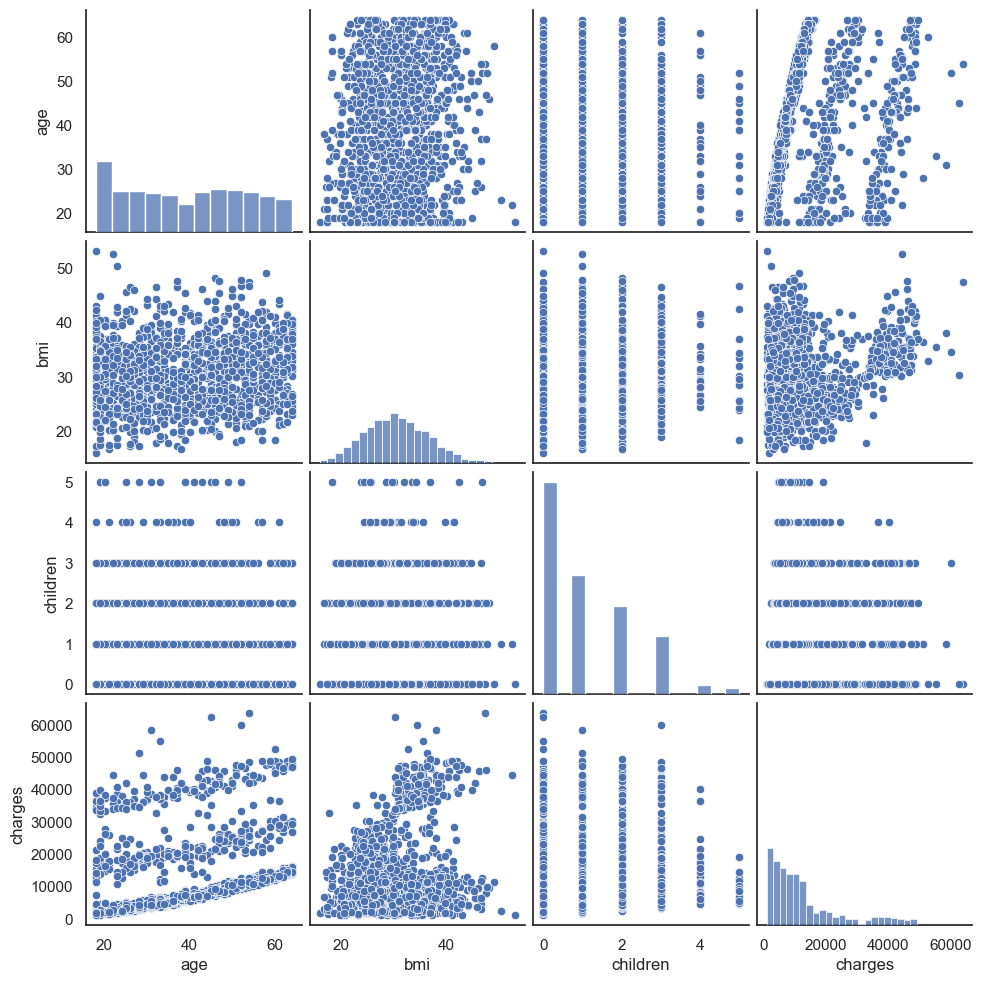

In [191]:
df.dropna(inplace=True) # remove null values first
sns.pairplot(df);

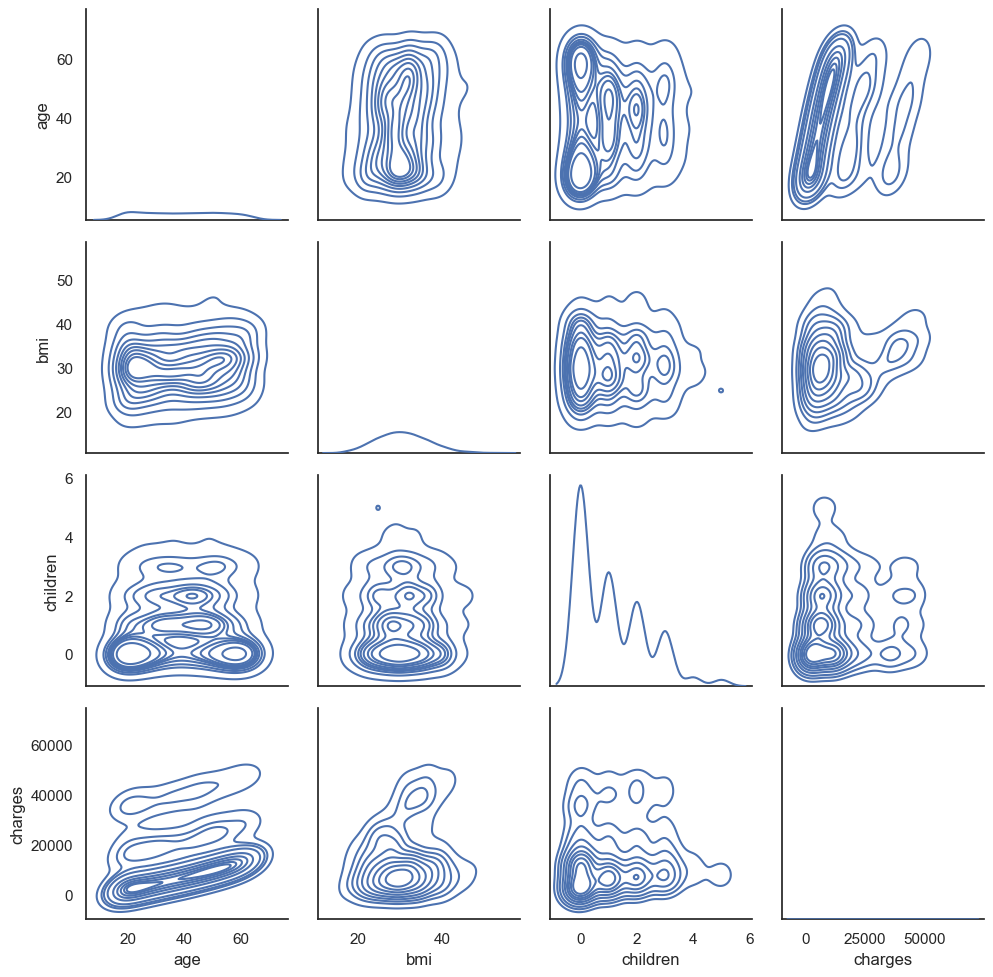

In [193]:
g = sns.PairGrid(df)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot, n_levels=10);

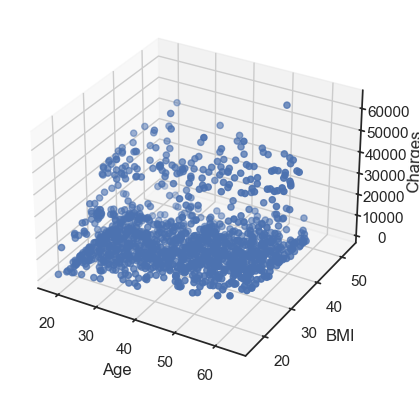

In [209]:
# The following two lines change the font size of matplotlib
font = {"size": 8}
plt.rc("font", **font)

fig = plt.figure()
three_d_plot = fig.add_subplot(projection='3d')
three_d_plot.scatter(df.age, df.bmi, df.charges)

three_d_plot.set_xlabel("Age")
three_d_plot.set_ylabel("BMI")
three_d_plot.set_zlabel("Charges")

plt.show()

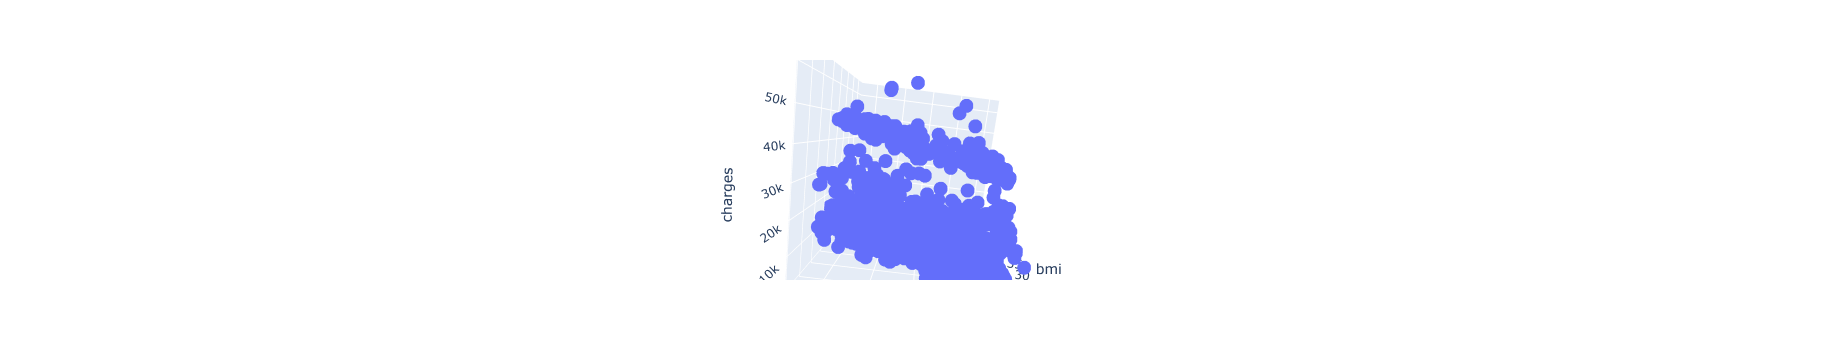

In [215]:
fig = px.scatter_3d(df, x="age", y="charges", z="bmi")
fig.show()

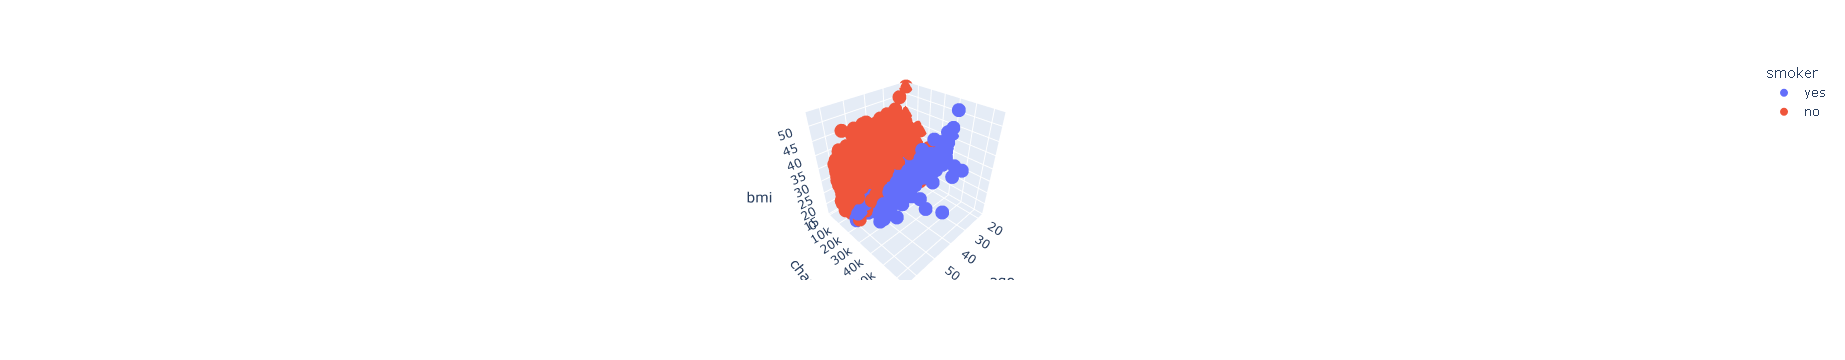

In [217]:
fig = px.scatter_3d(df, x="age", y="charges", z="bmi", color="smoker")
fig.show()

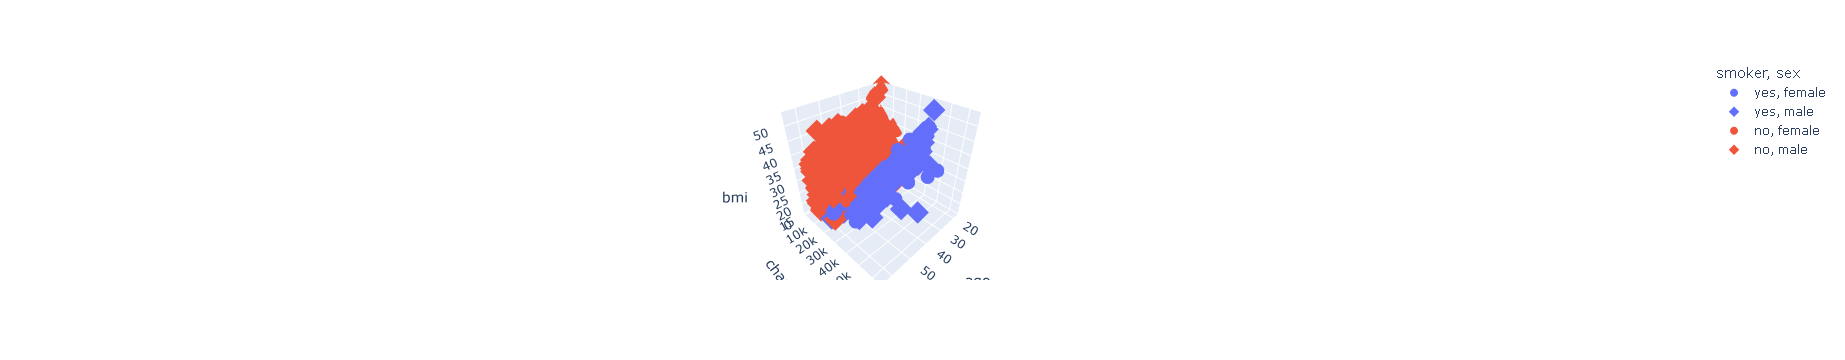

In [219]:
fig = px.scatter_3d(df, x="age", y="charges", z="bmi", color="smoker", symbol="sex")
fig.show()

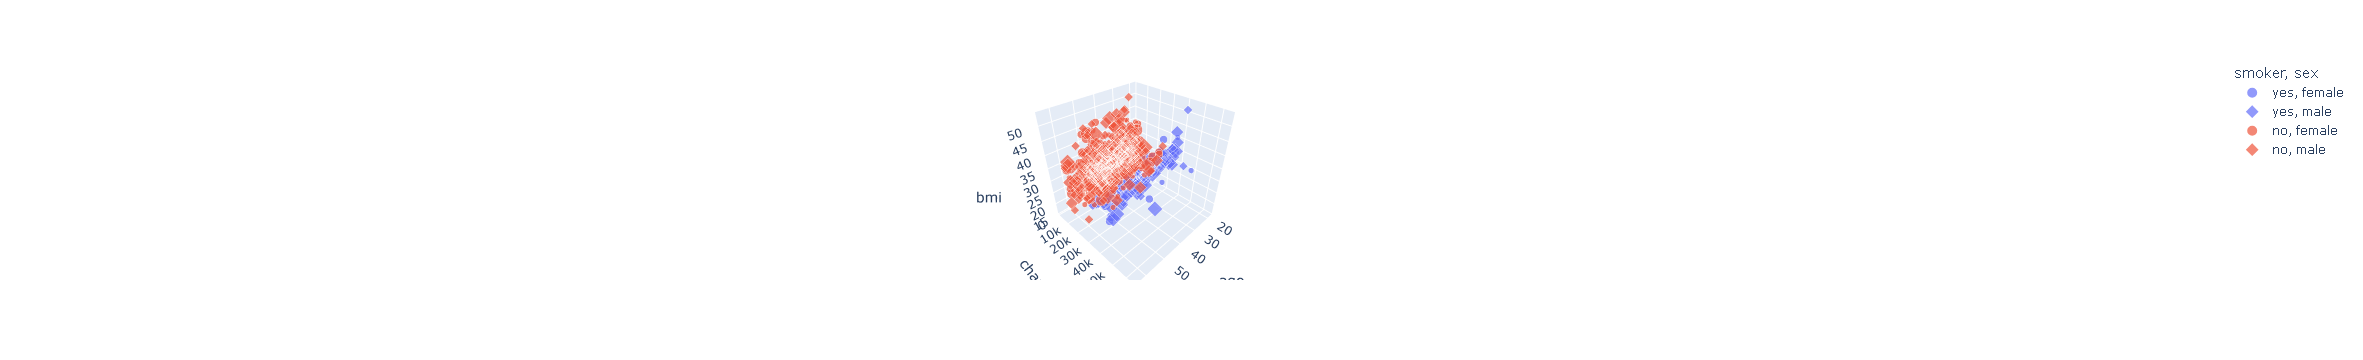

In [221]:
fig = px.scatter_3d(df, x="age", y="charges", z="bmi", color="smoker", symbol="sex", size="children")
fig.show()